In [1]:
import torch
import transformers
import sys
import os
import matplotlib.pyplot as plt
import json
import seaborn as sns
import collections
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../")
from utils import experiment_logger
from secalign_refactored import secalign, config
# 模型路径
model_rel_path = "/home/dataset/2024_zox_llm/code/better_opts_attacks/secalign_refactored/secalign_models/mistralai/Mistral-7B-v0.1_SpclSpclSpcl_None_2025-03-12-01-02-08"

load_model = True
load_tokenizer = True
max_memory = {0: "10GiB", 1: "10GiB",2: "10GiB",  3: "10GiB", "cpu": "16GiB"}#2: "10GiB",
if load_model and load_tokenizer:
    model, tokenizer, frontend_delimiters, _ = secalign.load_lora_model(model_rel_path, load_model=load_model, device_map="auto",max_memory=max_memory)

    inst_delm = config.DELIMITERS[frontend_delimiters][0]
    data_delm = config.DELIMITERS[frontend_delimiters][1]
    resp_delm = config.DELIMITERS[frontend_delimiters][2]

    prompt_template = config.PROMPT_FORMAT[frontend_delimiters]
    model = model.eval()
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.temperature = 0.0
    model.generation_config.do_sample=False
elif load_tokenizer and not load_model:
    model = None
    configs = model_rel_path.split('/')[-1].split('_') + ['Frontend-Delimiter-Placeholder', 'None']
    for alignment in ['dpo', 'kto', 'orpo']:
        base_model_index = model_rel_path.find(alignment) - 1
        if base_model_index > 0: break
        else: base_model_index = False

    base_model_path = model_rel_path[:base_model_index] if base_model_index else model_rel_path
    frontend_delimiters = configs[1] if configs[1] in config.DELIMITERS else base_model_path.split('/')[-1]
    training_attacks = configs[2]

    tokenizer = transformers.AutoTokenizer.from_pretrained(base_model_path)

    prompt_template = config.PROMPT_FORMAT[frontend_delimiters]["prompt_input"]

else:
    model, tokenizer, frontend_delimiters, _ = None, None, None, None


模型地址为 /home/dataset/2024_zox_llm/code/better_opts_attacks/secalign_refactored/secalign_models/mistralai/Mistral-7B-v0.1_SpclSpclSpcl_None_2025-03-12-01-02-08


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


缺少默认的 chat 模板


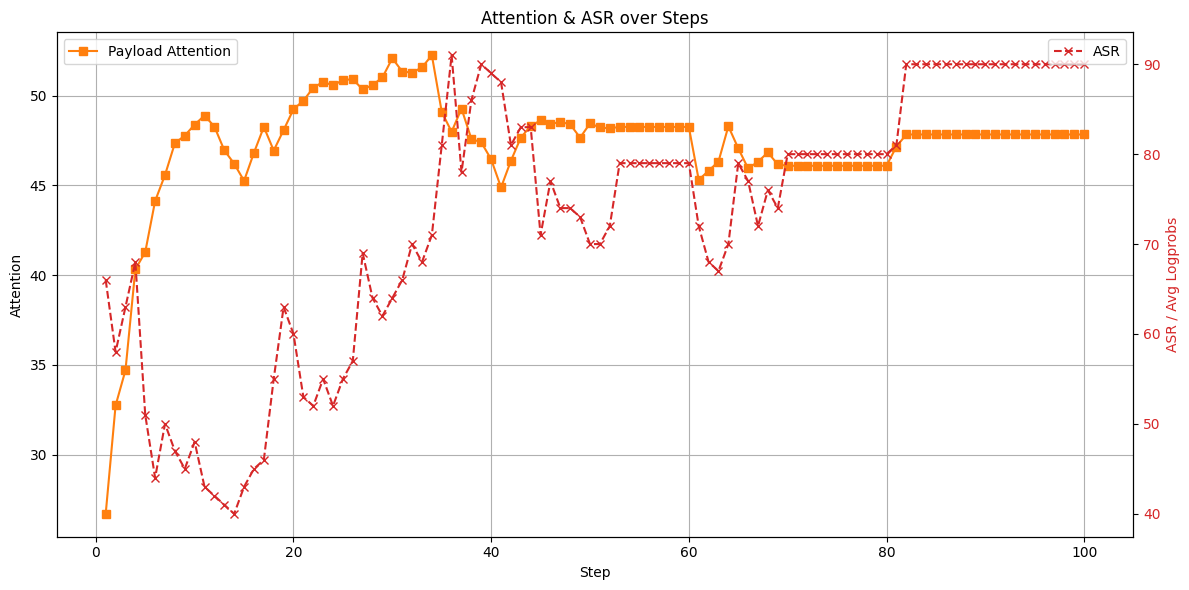

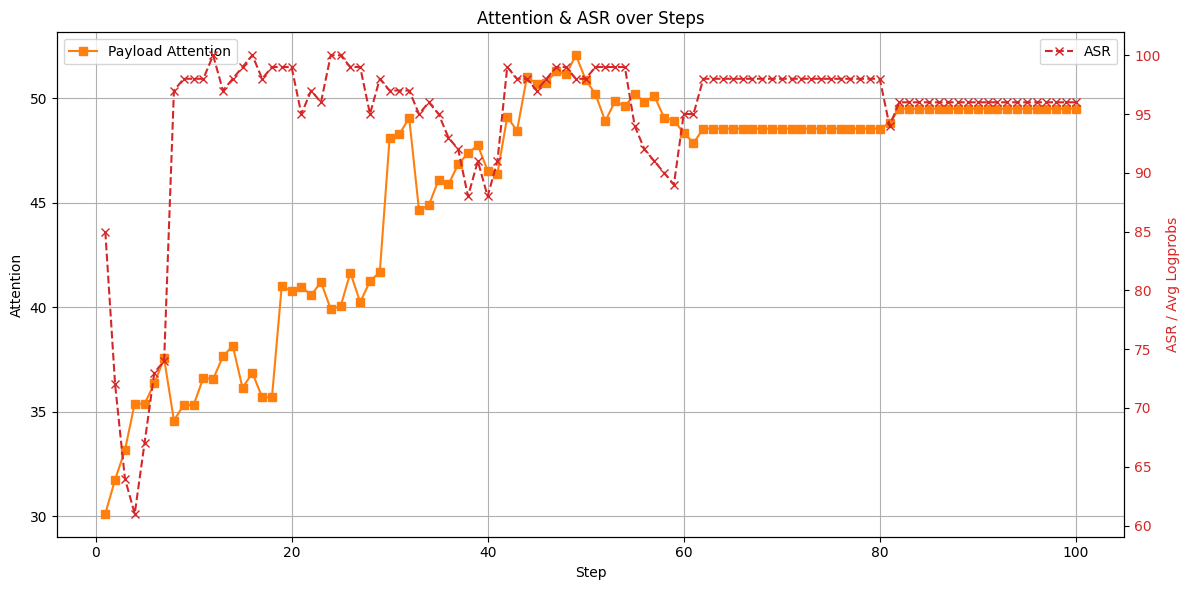

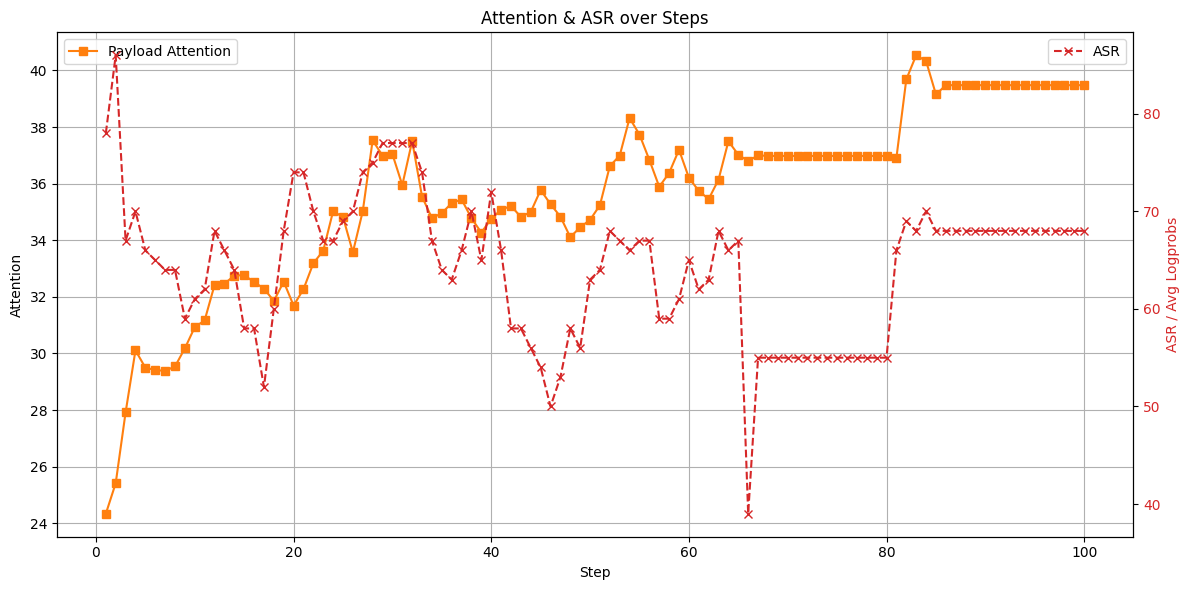

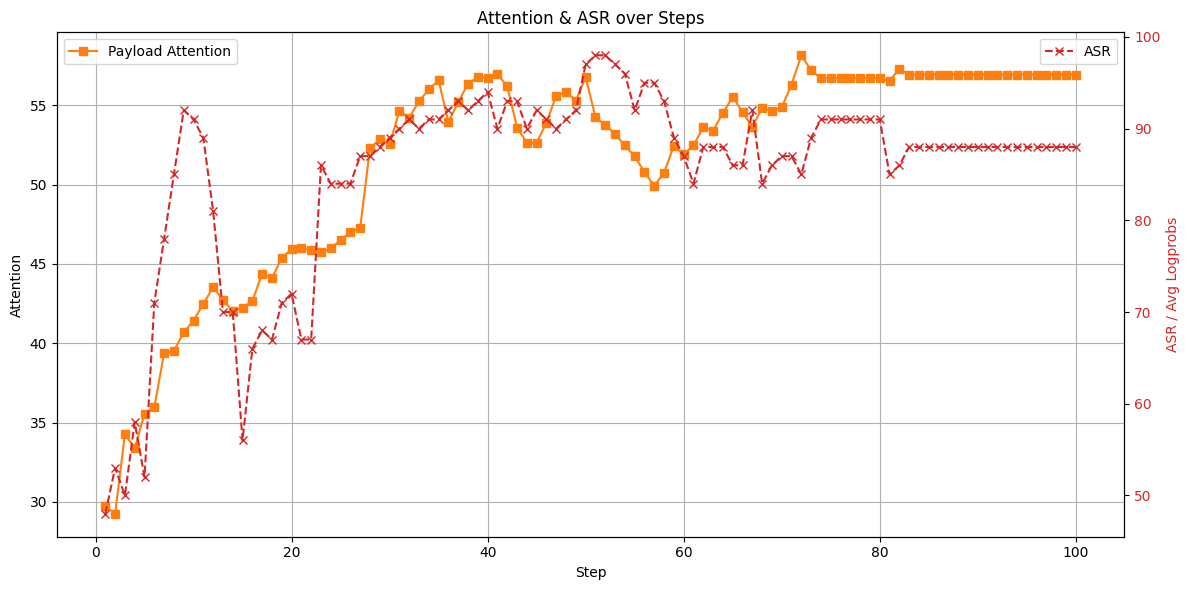

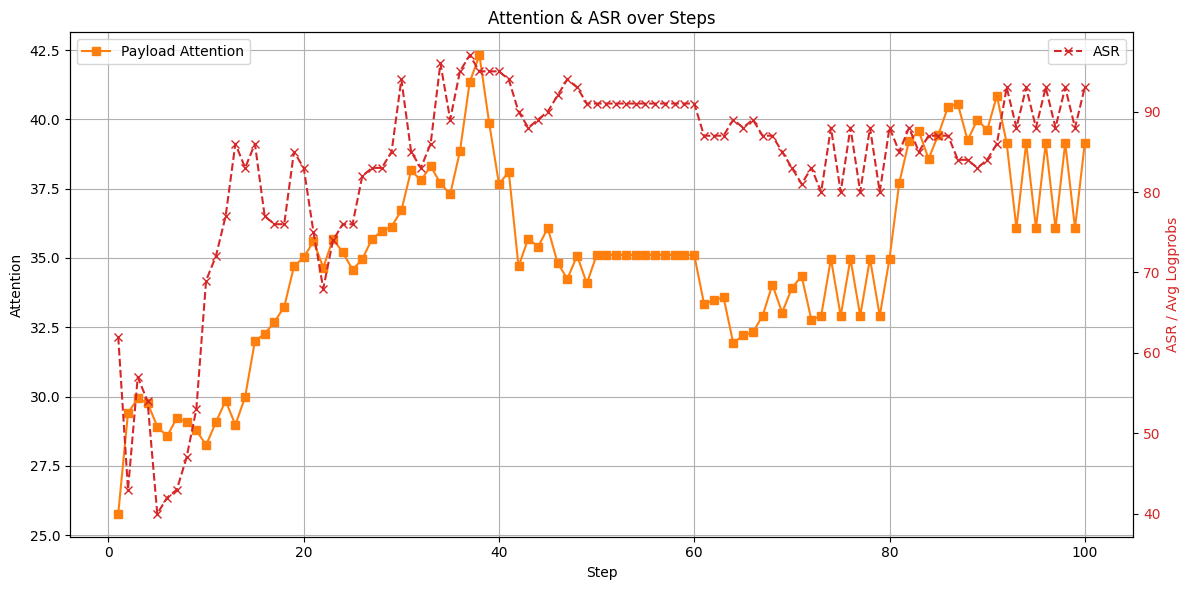

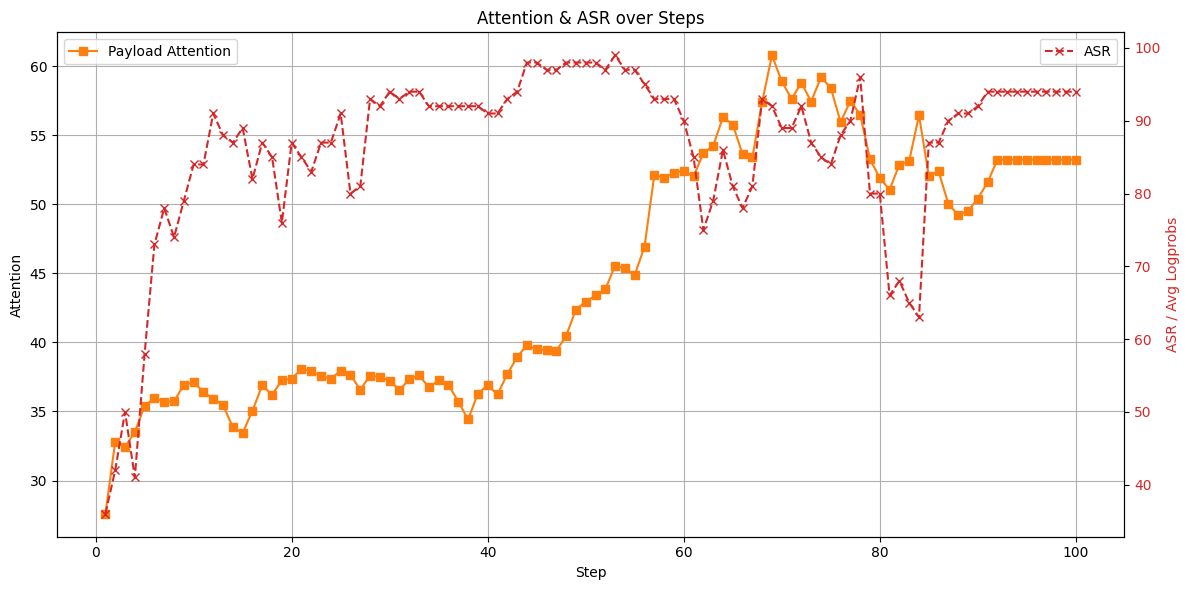

In [8]:

trigger = "i watched 3D movie"
payload_tokens = torch.tensor(tokenizer.encode(trigger))

models = [model]
dataset_name = "sst2"
from utils import attack_utility

def plot_training_logs(logger, num_rounds, points_per_round, gap=5):

    astra_tokens_seq_result = list(logger.query({"variable_name": "astra_tokens_sequences_list"}))
    prefix_suffix_attn_result = list(logger.query({"variable_name": "prefix_suffix_attention_list"}))
    payload_attn_result = list(logger.query({"variable_name": "payload_attention_list"}))
    background_attn_result = list(logger.query({"variable_name": "other_attention_list"}))
    asr_result = list(logger.query({"variable_name": "astra_logprobs_lists_list"}))

    loss = list(logger.query({"variable_name": "current_best_true_loss_chunk"}))

    # # 展成一维list
    # flattened_logprobs = [val for group in asr_result for val in group]
    # astra_logprobs_tensor = torch.tensor(flattened_logprobs)[0]
    # maximum_attack_idx = torch.argmax(astra_logprobs_tensor)
    # formatted_result= list(logger.query({"variable_name": "formatted_result_list"}))
    # formatted_result = formatted_result[len(formatted_result) - 1][maximum_attack_idx]


    # asr = attack_utility.compute_average_asr(models,tokenizer,formatted_result,payload_tokens,10000,[1],dataset_name,True,None)
    # print(f"Testdataset_ASR: {asr}")

    # ca = 100 - attack_utility.compute_average_asr(models,tokenizer,formatted_result,payload_tokens,10000,[0,1],dataset_name,False,None)
    # print(f"Testdataset_CA: {ca}")


    prefix_suffix_attn_result = prefix_suffix_attn_result[points_per_round -1]
    payload_attn_result = payload_attn_result[points_per_round-1]
    background_attn_result = background_attn_result
    asr_result = asr_result[0][0]


    steps = list(range(1, points_per_round + 1))  # x 轴步数

    fig, ax1 = plt.subplots(figsize=(12,6))

    # 左 y 轴 - 注意力
    # ax1.plot(steps, prefix_suffix_attn_result, label="Prefix+Suffix Attention", marker='o', color='tab:blue')
    ax1.plot(steps, payload_attn_result, label="Payload Attention", marker='s', color='tab:orange')
    # ax1.plot(steps, background_attn_result, label="Other Attention", marker='^', color='tab:green')
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Attention", color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True)
    ax1.legend(loc='upper left')

    # 右 y 轴 - ASR
    ax2 = ax1.twinx()
    ax2.plot(steps, asr_result, label="ASR", marker='x', linestyle='--', color='tab:red')
    ax2.set_ylabel("ASR / Avg Logprobs", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')

    plt.title("Attention & ASR over Steps")
    plt.tight_layout()
    plt.show()


# logger_sst_2_0_25 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25/")
# plot_training_logs(logger_sst_2_0_25,1,100)
logger = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25_20251129_223332")
plot_training_logs(logger,1,100)

logger1 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25_20251130_020049")
plot_training_logs(logger1,1,100)

logger2 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_2_20251130_133304")
plot_training_logs(logger2,1,100)

logger3 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_2_20251130_165927")
plot_training_logs(logger3,1,100)

logger4 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_2_20251130_202724")
plot_training_logs(logger4,1,100)

# logger5 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_2_20251201_032211")
# plot_training_logs(logger5,1,100)

# logger6 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_2_20251201_032231")
# plot_training_logs(logger6,1,100)

# logger7 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_2_20251201_032247")
# plot_training_logs(logger7,1,100)

logger8 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst2_4_20251130_235516")
plot_training_logs(logger8,1,100)



